# 💬 Sentiment Analysis with NLP

**Goal:** teach a computer to read a product review and decide: positive 😊 or negative 😞?

This is **NLP** (Natural Language Processing) — machine learning on text.
Computers can't read words directly, so first we convert text into numbers.

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline

## Step 1: Load the data

5000 product reviews, labeled `positive` or `negative`. Balanced: 2500 of each.

In [2]:
df = pd.read_csv("data/reviews.csv")
print(df.head())
print("\nShape:", df.shape)
print(df["Sentiment"].value_counts())

                                              Review Sentiment
0  Perfect phone for my needs, absolutely outstan...  positive
1           Terrible laptop! The quality is useless.  negative
2  I would never buy this laptop again, it is worst.  negative
3          The watch is awesome, I use it every day.  positive
4   Top quality watch, genuinely perfect experience.  positive

Shape: (5000, 2)
Sentiment
positive    2500
negative    2500
Name: count, dtype: int64


## Step 2: Clean the text 🧹

ML models need clean, consistent input. Our cleaning function:
1. **lowercase** — "Great" and "great" become the same word
2. **remove punctuation and numbers** — "amazing!!!" becomes "amazing"

In [3]:
def clean_text(text):
    text = text.lower()                 # lowercase everything
    text = re.sub(r"[^a-z\s]", "", text)  # keep only letters and spaces
    text = re.sub(r"\s+", " ", text).strip()  # collapse extra spaces
    return text

df["Cleaned"] = df["Review"].apply(clean_text)

print("BEFORE:", df["Review"].iloc[0])
print("AFTER: ", df["Cleaned"].iloc[0])

BEFORE: Perfect phone for my needs, absolutely outstanding.
AFTER:  perfect phone for my needs absolutely outstanding


## Step 3: Text → numbers with TF-IDF 🔢

`TfidfVectorizer` turns each review into a row of numbers — one column per word.

**What TF-IDF does, simply:** it counts how often each word appears in a review,
but gives *less* weight to words that appear in *every* review (like "the", "is").
So rare, meaningful words like "amazing" or "terrible" get high scores,
and boring common words get low scores. The model then learns from these scores.

In [4]:
vectorizer = TfidfVectorizer(max_features=1000)  # keep the 1000 most useful words
X = vectorizer.fit_transform(df["Cleaned"])     # text -> number matrix
y = df["Sentiment"]                             # labels: positive / negative

print("Matrix shape:", X.shape)  # 5000 reviews x 1000 word-columns
print("Example words:", list(vectorizer.get_feature_names_out()[:10]))

Matrix shape: (5000, 116)
Example words: ['absolutely', 'again', 'all', 'always', 'am', 'amazing', 'and', 'are', 'awesome', 'awful']


## Step 4: Train / test split + Logistic Regression

We train on 80% of reviews and test on 20% the model has never seen.
`LogisticRegression` learns which words push a review toward positive or negative.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

preds = model.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, preds), 4))

Accuracy: 1.0


## Step 5: Confusion matrix

Accuracy is one number — the confusion matrix shows *what kind* of mistakes the model makes.

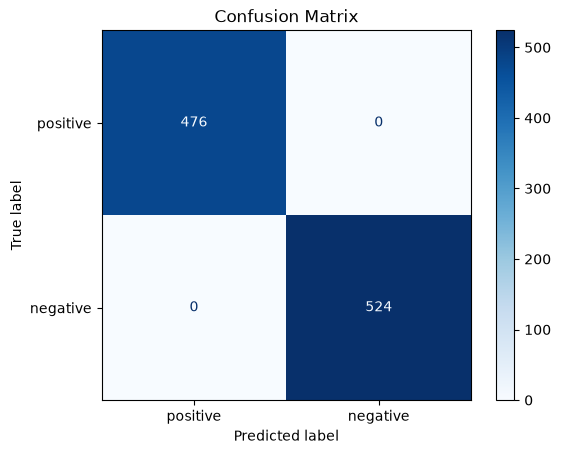

In [6]:
cm = confusion_matrix(y_test, preds, labels=["positive", "negative"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["positive", "negative"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

## Step 6: Which words matter most? 🔍

Each word got a coefficient from the model:
- **large positive** coefficient → pushes toward **positive** 😊
- **large negative** coefficient → pushes toward **negative** 😞

Let's look at the top 10 of each.

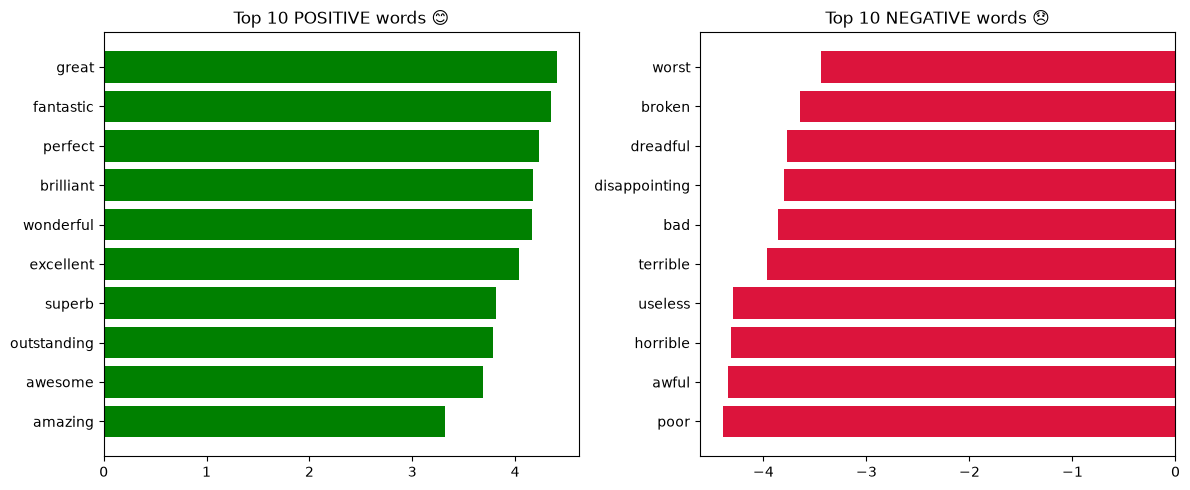

In [7]:
words = np.array(vectorizer.get_feature_names_out())
coefs = model.coef_[0]

top_pos_idx = np.argsort(coefs)[-10:][::-1]   # 10 most positive
top_neg_idx = np.argsort(coefs)[:10]          # 10 most negative

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].barh(words[top_pos_idx][::-1], coefs[top_pos_idx][::-1], color="green")
axes[0].set_title("Top 10 POSITIVE words 😊")

axes[1].barh(words[top_neg_idx], coefs[top_neg_idx], color="crimson")
axes[1].set_title("Top 10 NEGATIVE words 😞")

plt.tight_layout()
plt.show()

## Step 7: Try it on new sentences! 🎮

The pipeline: clean → vectorize → predict. Let's test 3 reviews the model never saw.

In [8]:
new_reviews = [
    "This phone is amazing, I love it!",
    "Terrible laptop, broke after two days.",
    "The watch is okay, nothing special.",
]

for r in new_reviews:
    cleaned = clean_text(r)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    print(f"{pred:>8}  <-  {r}")

positive  <-  This phone is amazing, I love it!
negative  <-  Terrible laptop, broke after two days.
negative  <-  The watch is okay, nothing special.


## Key takeaway ✅

1. **Text must become numbers** before ML — TF-IDF does this, weighting meaningful words higher.
2. **Cleaning matters** — lowercase + punctuation removal keeps the vocabulary small and consistent.
3. The model doesn't "understand" reviews — it learned that words like "amazing" → positive and "terrible" → negative.
4. Always check a **confusion matrix**, not just accuracy — it shows *where* the model fails.